## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import chi2, spearmanr, wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import format_stats, show_source

## Functions

In [2]:
show_source(format_stats)

In [3]:
def events_recounted(event_matches, n_events):
    """
    Binary vector indicating which episode events a participant described in a
    given session. A participant who returned to the same episode event more
    than once within a session is counted only once.
    """
    recounted = np.zeros(n_events, dtype=int)
    recounted[np.unique(event_matches)] = 1
    return recounted

In [4]:
def cochrans_q(recounted):
    """
    Cochran's Q test for a (participants x episode events) binary matrix, under
    the null hypothesis that every episode event was equally likely to be
    recounted. Q is distributed as chi-squared with (n_events - 1) degrees of
    freedom.

    Unlike a goodness-of-fit test on the per-event totals, Q conditions on the
    number of events each participant described. That matters here: a
    participant can describe a given episode event at most once, and describes
    most of them, so treating each description as an independent draw would
    badly overestimate how much the per-event totals should vary by chance.
    """
    n_events = recounted.shape[1]
    event_counts = recounted.sum(axis=0)
    participant_counts = recounted.sum(axis=1)
    numerator = n_events * (n_events - 1) * ((event_counts - event_counts.mean()) ** 2).sum()
    denominator = n_events * participant_counts.sum() - (participant_counts ** 2).sum()
    q = numerator / denominator
    df = n_events - 1
    return q, df, chi2.sf(q, df)

## Load data

In [5]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
n_events = len(atlep1.events)

In [6]:
imm_recounted = np.array(
    [events_recounted(p.event_matches['atlep1'], n_events) for p in participants]
)
del_recounted = np.array(
    [events_recounted(p.event_matches['delayed'], n_events) for p in participants]
)

imm_rates = imm_recounted.mean(axis=0)
del_rates = del_recounted.mean(axis=0)

## Do participants recount fewer episode events after the delay?

In [7]:
n_imm = imm_recounted.sum(axis=1)
n_del = del_recounted.sum(axis=1)

T, p = wilcoxon(n_imm, n_del, alternative='greater')
T, p = T.item(), p.item()
print(f'mean episode events recounted immediately: {n_imm.mean():.2f}')
print(f'mean episode events recounted after the delay: {n_del.mean():.2f}')
print(f'{T=}, {p=:.4e}')

mean episode events recounted immediately: 16.98
mean episode events recounted after the delay: 16.26
T=581.0, p=3.3742e-03


## Are some episode events more likely to be recounted than others?

In [8]:
for session, recounted in (('immediate', imm_recounted), ('delayed', del_recounted)):
    Q, df, p = cochrans_q(recounted)
    rates = recounted.mean(axis=0)
    print(f'{session} recall:')
    print(f'  proportion of participants recounting each episode event: '
          f'min={rates.min():.2f}, max={rates.max():.2f}, mean={rates.mean():.2f}')
    print(f'  {Q=:.2f}, {df=}, {p=:.4e}')

immediate recall:
  proportion of participants recounting each episode event: min=0.64, max=0.96, mean=0.85
  Q=75.07, df=19, p=1.2936e-08
delayed recall:
  proportion of participants recounting each episode event: min=0.58, max=0.98, mean=0.81
  Q=73.82, df=19, p=2.1086e-08


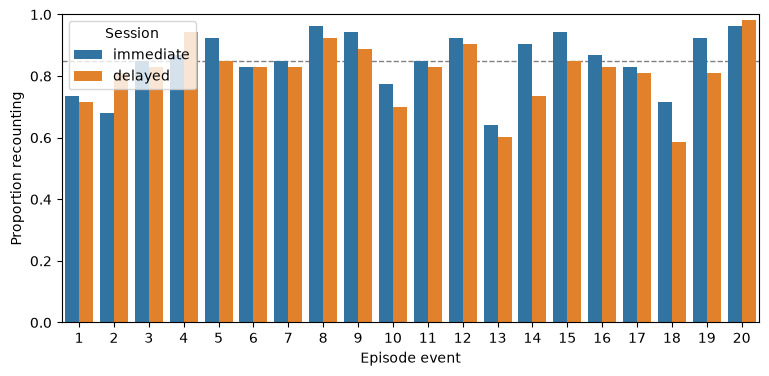

In [9]:
df = pd.DataFrame(columns=('Session', 'Episode event', 'Proportion recounting'))
df['Session'] = np.repeat(['immediate', 'delayed'], n_events)
df['Episode event'] = np.tile(np.arange(1, n_events + 1), 2)
df['Proportion recounting'] = np.concatenate((imm_rates, del_rates))

fig, ax = plt.subplots(1, figsize=(9, 4))
ax = sns.barplot(df, x='Episode event', y='Proportion recounting', hue='Session')
ax.axhline(imm_rates.mean(), c='grey', ls='--', lw=1, zorder=0)
ax.set_ylim(0, 1)
plt.show()

## Does the distribution of recounted events change across the delay?

In [10]:
rho, p = spearmanr(imm_rates, del_rates)
rho, p = rho.item(), p.item()
print(f'immediate vs delayed proportions across episode events: {rho=:.3f}, {p=:.4e}')

immediate vs delayed proportions across episode events: rho=0.795, p=2.8189e-05


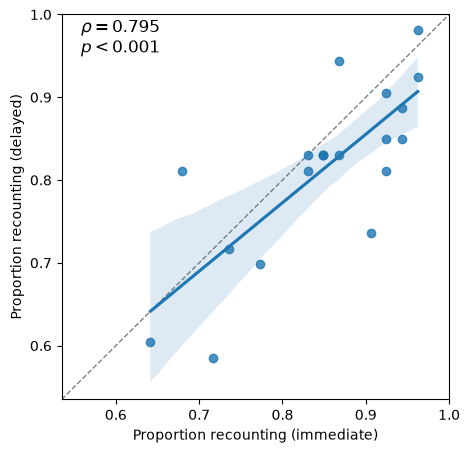

In [11]:
fig, ax = plt.subplots(1, figsize=(5, 5))
ax = sns.regplot(x=imm_rates, y=del_rates)
lims = (min(imm_rates.min(), del_rates.min()) - 0.05, 1)
ax.plot(lims, lims, c='grey', ls='--', lw=1, zorder=0)
ax.set(xlim=lims,
       ylim=lims,
       xlabel='Proportion recounting (immediate)',
       ylabel='Proportion recounting (delayed)')

rho, p = spearmanr(imm_rates, del_rates)
ax.text(0.05, 0.9, format_stats(rho, p, r'\rho'), transform=ax.transAxes, fontsize='large')
plt.show()